# SVD for Data Compression

Image shape: (400, 600)


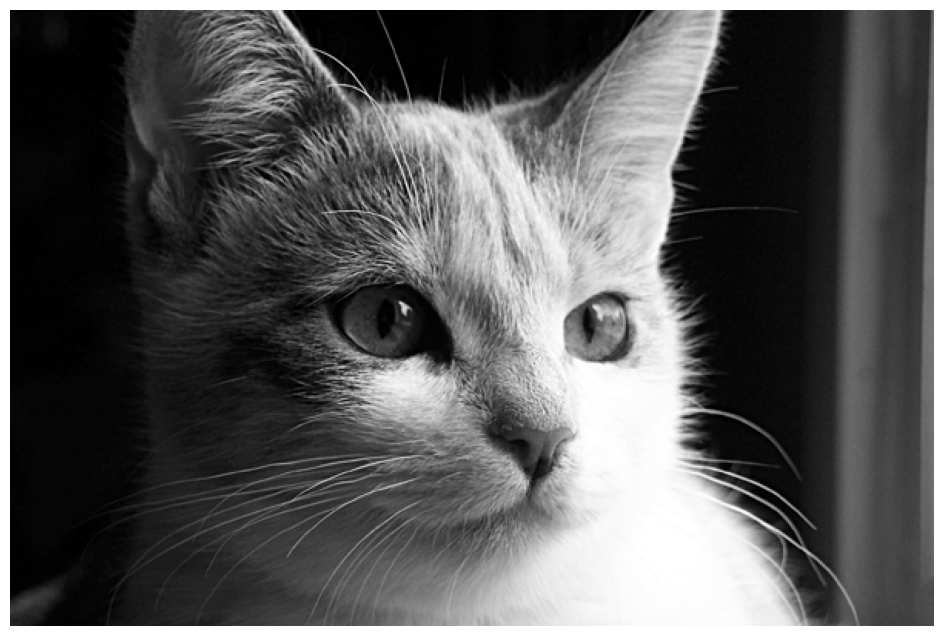

In [ ]:
from matplotlib.image import imread
import matplotlib.pyplot as plt
import numpy as np
import os
plt.rcParams['figure.figsize'] = [16, 8]

# Read the image
X = imread(os.path.join('grayscale_cat.jpg'))
#X = np.mean(A, -1); # Convert RGB to grayscale
print("Image shape:", X.shape)
# Space for storing X is proportional to the number of pixels
storage_X = X.size

# Visualize the original image
img = plt.imshow(X)
img.set_cmap('gray')
plt.axis('off')
plt.show()

Rank 5 approximation:
U shape: (400, 5)
S shape: (5, 5)
VT shape: (5, 600)
X_approx: (400, 600)
Rank 20 approximation:
U shape: (400, 20)
S shape: (20, 20)
VT shape: (20, 600)
X_approx: (400, 600)
Rank 100 approximation:
U shape: (400, 100)
S shape: (100, 100)
VT shape: (100, 600)
X_approx: (400, 600)


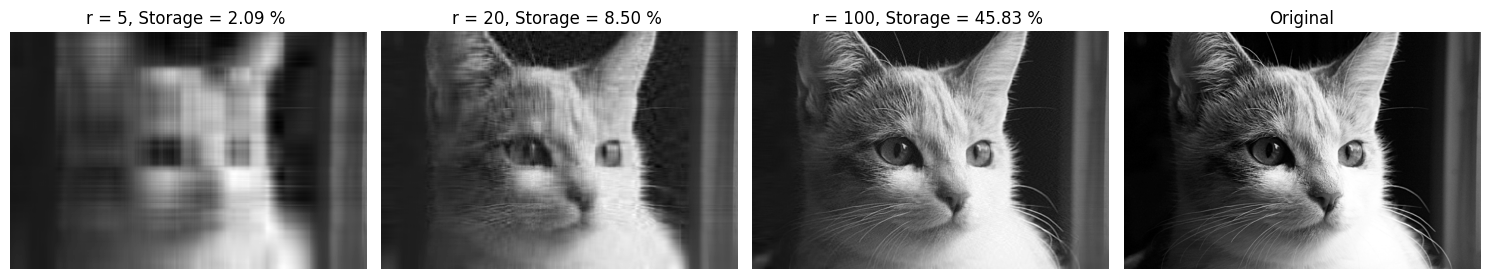

In [ ]:
# Perform SVD
U, S, VT = np.linalg.svd(X,full_matrices=False)
S = np.diag(S)

# Rank-r approximation
r_values = [5, 20, 100]

# Create subplots
fig, axes = plt.subplots(1, len(r_values) + 1, figsize=(15, 5))

for i, r in enumerate(r_values):
    # Construct approximate image using r largest singular values and corresponding singular vectors
    X_approx = U[:, :r] @ S[:r, :r] @ VT[:r, :]
    ## print the shape of U, S, VT, and X_approx
    print(f"Rank {r} approximation:")
    print("U shape:", U[:, :r].shape)
    print("S shape:", S[:r, :r].shape)
    print("VT shape:", VT[:r, :].shape)
    print("X_approx:", X_approx.shape)
    storage_X_approx = U[:, :r].size + S[:r, :r].size + VT[:r, :].size
    storage_percent = (storage_X_approx / storage_X) * 100

    # Plot the approximate image
    ax = axes[i]
    img = ax.imshow(X_approx, cmap='gray')
    ax.axis('off')
    ax.set_title(f'r = {r}, Storage = {storage_percent:.2f} % ')

# Plot the original image
ax = axes[len(r_values)]
img = ax.imshow(X, cmap='gray')
ax.axis('off')
ax.set_title('Original')


plt.tight_layout()
plt.show()

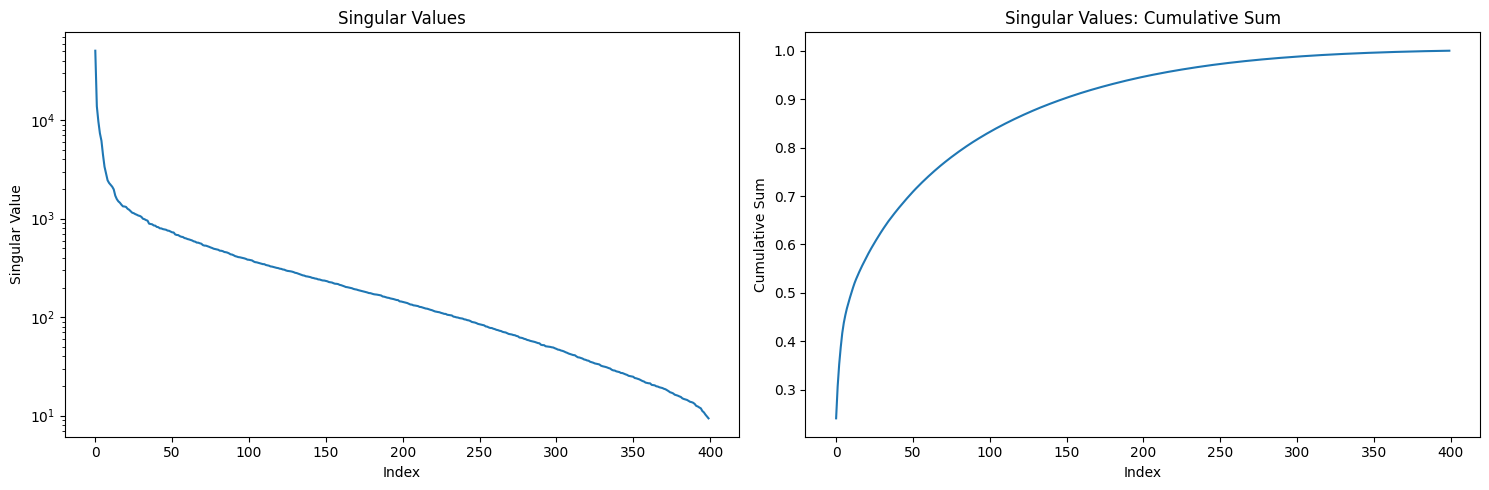

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot singular values
axes[0].semilogy(np.diag(S))
axes[0].set_title('Singular Values')
axes[0].set_xlabel('Index')
axes[0].set_ylabel('Singular Value')

# Plot cumulative sum of singular values
cumulative_sum = np.cumsum(np.diag(S)) / np.sum(np.diag(S))
axes[1].plot(cumulative_sum)
axes[1].set_title('Singular Values: Cumulative Sum')
axes[1].set_xlabel('Index')
axes[1].set_ylabel('Cumulative Sum')

plt.tight_layout()
plt.show()